In [51]:
%pip install yfinance arch pandas numpy matplotlib seaborn statsmodels

Note: you may need to restart the kernel to use updated packages.


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from arch import arch_model
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import warnings
warnings.filterwarnings('ignore')

csv_path = '../../data/sp500_top30/TSLA_1d_2017-01-01_2026-03-01.csv'
data = pd.read_csv(csv_path, index_col=0, parse_dates=True)

if 'Adj Close' in data.columns:
    close_col = 'Adj Close'
elif 'adj_close' in data.columns:
    close_col = 'adj_close'
elif 'Close' in data.columns:
    close_col = 'Close'
else:
    close_col = data.select_dtypes(include=[np.number]).columns[0]

# Calculate the yields
data['Returns'] = 100 * data[close_col].pct_change()
data = data.dropna(subset=['Returns'])
print(data[[close_col, 'Returns']].tail())

             Adj Close   Returns
Date                            
2026-02-23  399.829987 -2.911471
2026-02-24  409.380005  2.388520
2026-02-25  417.399994  1.959057
2026-02-26  408.579987 -2.113083
2026-02-27  402.510010 -1.485628


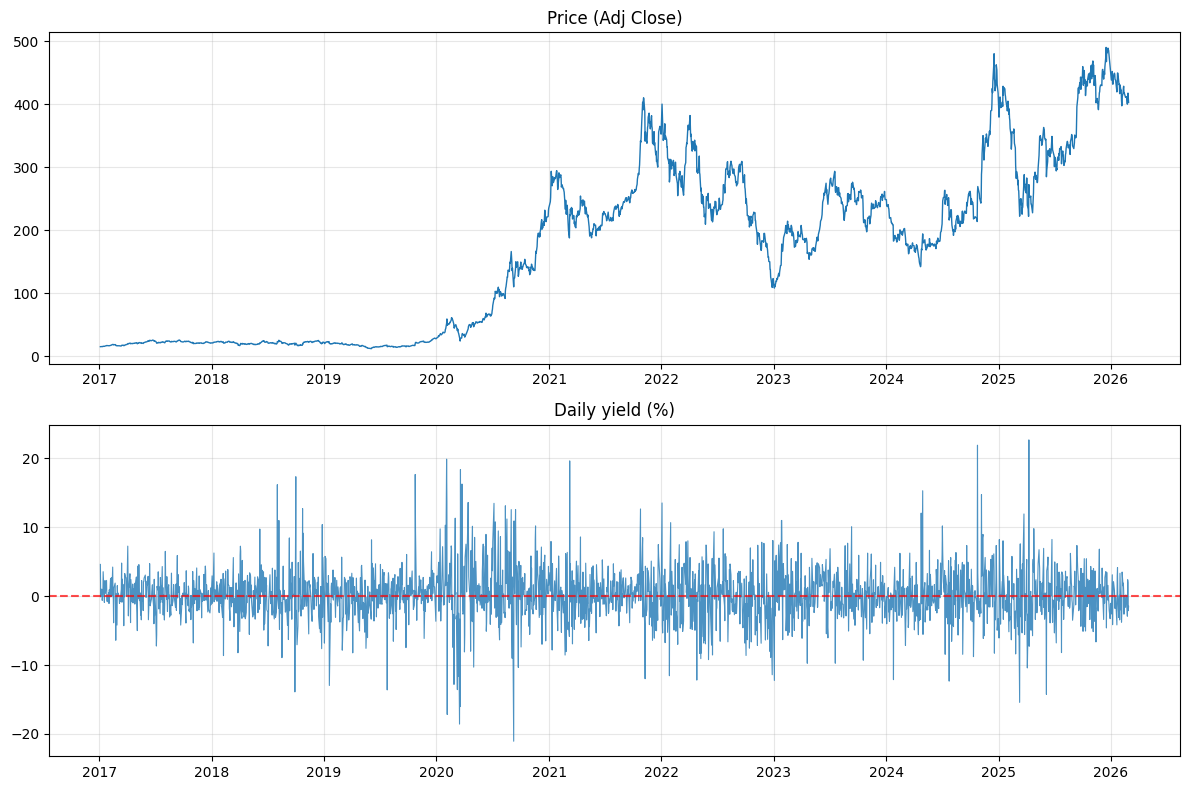

In [53]:
# Define the close variable for reuse
close_col = 'Adj Close' if 'Adj Close' in data.columns else data.columns[0]

fig, ax = plt.subplots(2, 1, figsize=(12, 8))

# Prices
ax[0].plot(data.index, data[close_col], linewidth=1)
ax[0].set_title(f'Price ({close_col})')
ax[0].grid(True, alpha=0.3)

# Yields
ax[1].plot(data.index, data['Returns'], linewidth=0.8, alpha=0.8)
ax[1].set_title('Daily yield (%)')
ax[1].axhline(0, color='red', linestyle='--', alpha=0.7)
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

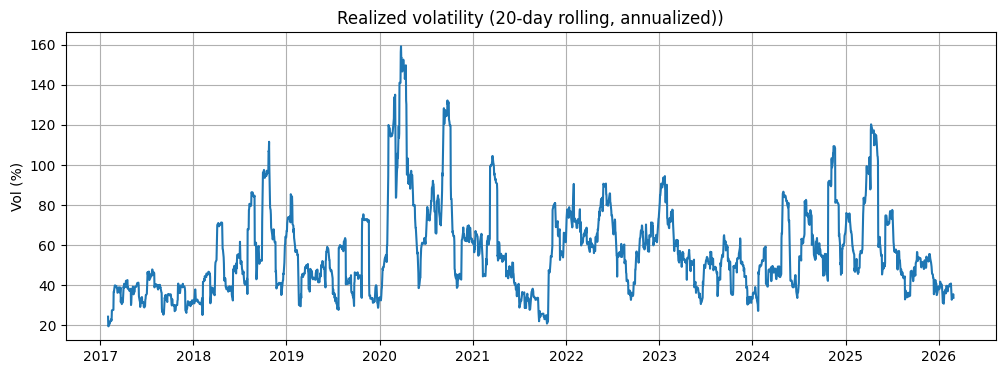

In [54]:
data['Vol_Realisee'] = data['Returns'].rolling(window=20).std() * np.sqrt(252)
plt.figure(figsize=(12, 4))
plt.plot(data.index, data['Vol_Realisee'])
plt.title('Realized volatility (20-day rolling, annualized))')
plt.ylabel('Vol (%)')
plt.grid(True)
plt.show()

In [55]:
# Prepare the yields (already in % normally)
returns = data['Returns'].dropna()

# Fit GARCH(1,1) 
model = arch_model(returns, vol='Garch', p=1, q=1)
res = model.fit(disp='off')
print(res.summary())

# Forecast (30 days)
forecast = res.forecast(horizon=30)

# Correct access to variance
vol_forecast = np.sqrt(forecast.variance.iloc[-1, -1:] * 252)
print(f'Forecast vol 30d (h=1): {vol_forecast.iloc[0]:.2f}%')

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                Returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -6228.75
Distribution:                  Normal   AIC:                           12465.5
Method:            Maximum Likelihood   BIC:                           12488.5
                                        No. Observations:                 2300
Date:                Sun, Mar 29 2026   Df Residuals:                     2299
Time:                        12:47:47   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.2034  7.444e-02      2.733  6.280e-03 [5.753e-0

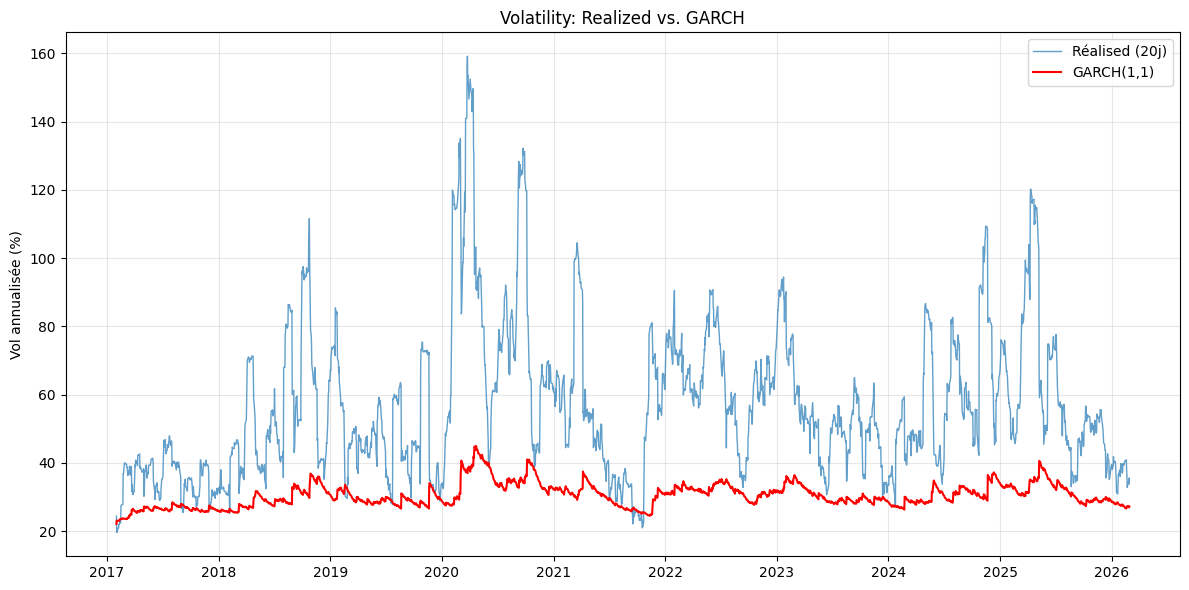

GARCH vs. Realized Correlation: 0.496


In [56]:
# Conditional volatility GARCH
fitted_vol = np.sqrt(res.conditional_volatility) * np.sqrt(252)
returns_idx = data['Returns'].dropna().index

# Perfect data alignment
vol_realised = data['Vol_Realisee'].reindex(returns_idx).dropna()
fitted_vol_aligned = pd.Series(fitted_vol, index=returns_idx[:len(fitted_vol)])

# Cut to a common length
min_len = min(len(vol_realised), len(fitted_vol_aligned))
vol_realised = vol_realised.iloc[:min_len]
fitted_vol_final = fitted_vol_aligned.iloc[:min_len].values

plt.figure(figsize=(12, 6))
plt.plot(vol_realised.index, vol_realised.values, label='Réalised (20j)', alpha=0.7, linewidth=1)
plt.plot(vol_realised.index, fitted_vol_final, label='GARCH(1,1)', color='red', linewidth=1.5)
plt.title('Volatility: Realized vs. GARCH')
plt.legend()
plt.ylabel('Vol annualisée (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

corr = np.corrcoef(vol_realised.values, fitted_vol_final)[0,1]
print(f'GARCH vs. Realized Correlation: {corr:.3f}')

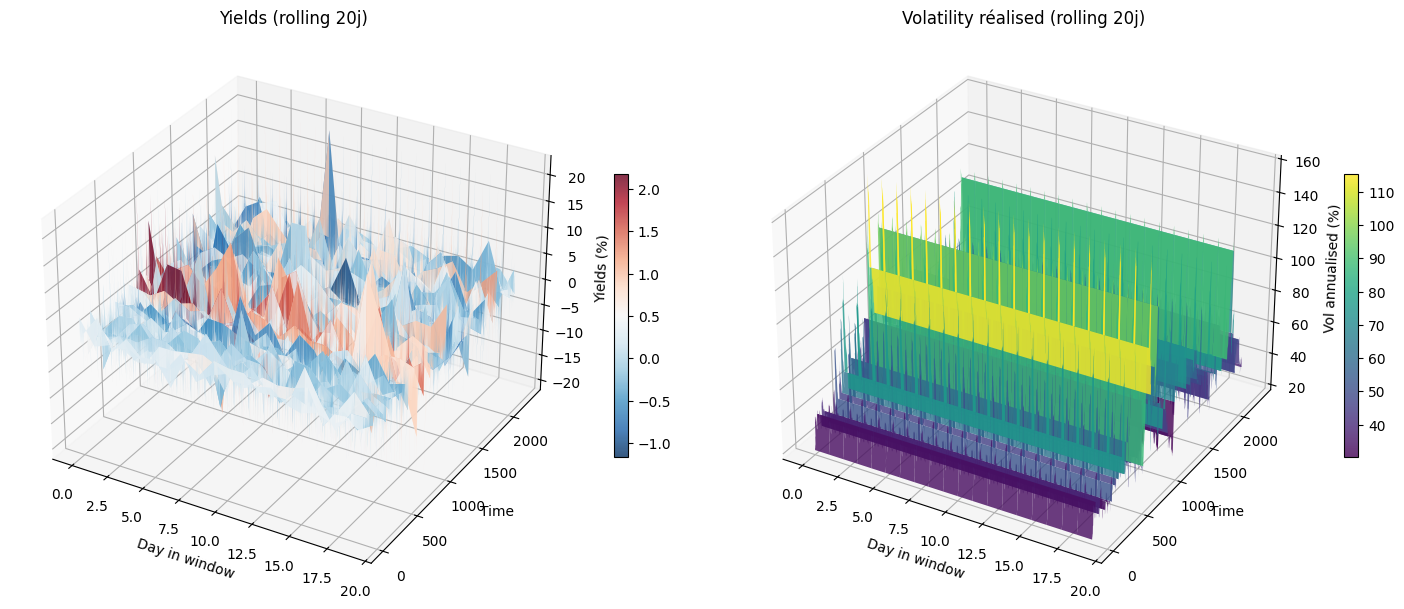

In [57]:
# Prepare the matrices for 3D surface
window = 20
n_days = len(data) - window
X = np.arange(window)
Y = np.arange(n_days)
X, Y = np.meshgrid(X, Y)

# Rolling mean/standard yields
Z_returns = np.array([data['Returns'].iloc[i:i+window].values for i in range(n_days)])

# Eolling Volatility
Z_vol = data['Vol_Realisee'].iloc[window:].values.reshape(-1, 1)
Z_vol = np.repeat(Z_vol, window, axis=1)

fig = plt.figure(figsize=(15, 6))

# Surface yields
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X, Y, Z_returns, cmap='RdBu_r', alpha=0.8)
ax1.set_title('Yields (rolling 20j)')
ax1.set_xlabel('Day in window')
ax1.set_ylabel('Time')
ax1.set_zlabel('Yields (%)')
plt.colorbar(surf1, ax=ax1, shrink=0.5)

# Volatility surface
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X, Y, Z_vol, cmap='viridis', alpha=0.8)
ax2.set_title('Volatility réalised (rolling 20j)')
ax2.set_xlabel('Day in window')
ax2.set_ylabel('Time')
ax2.set_zlabel('Vol annualised (%)')
plt.colorbar(surf2, ax=ax2, shrink=0.5)

plt.tight_layout()
plt.show()